# Librairy

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import combinations

# Data's import

## Data from 50_Breast_Cancer_WINTHIN_5Y

Femmes n'ayant pas eu de cancer avant l'inclusion (BC and not BC included without time constraints) for all time)

In [2]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "df_bc_ko_at_inclusion_361k_nb_BC_WITHIN_5Y.tsv"

# copy csv file from the bucket to the current working space
os.system(f"gsutil cp 'gs://fc-secure-4f907dc3-1aa1-4aaa-8566-86d601589221/Data/df_all_prs_298_305_311.csv' .")

print(f'[INFO] {name_of_file_in_bucket} is successfully downloaded into your working space')
# save dataframe in a csv file in the same workspace as the notebook
df_bc = pd.read_csv(name_of_file_in_bucket)
df_bc

Copying gs://fc-secure-4f907dc3-1aa1-4aaa-8566-86d601589221/Data/df_all_prs_298_305_311.csv...
\ [1 files][ 62.2 MiB/ 62.2 MiB]                                                
Operation completed over 1 objects/62.2 MiB.                                     


[INFO] df_bc_ko_at_inclusion_361k_nb_BC_WITHIN_5Y.tsv is successfully downloaded into your working space


,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,age_at_inclusion,has_bc
0,2028403,Female,1934-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2019-11-15,NaN,NaN,NaN,NaN,85.418207,0
1,7685408,Female,2002-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2022-11-03,NaN,NaN,NaN,NaN,20.386037,0
2,2299281,Female,1937-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2019-03-06,NaN,NaN,NaN,NaN,81.722108,0
3,2047635,Female,1941-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2018-11-09,NaN,NaN,NaN,NaN,77.401780,0
4,1608049,Female,1939-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2018-10-29,NaN,NaN,NaN,NaN,79.373032,0
...,...,...,...,...,...,...,...,...,...,...,...,...
360881,1133616,Female,2001-06-15,Not Hispanic or Latino,White,2019-05-20,NaN,NaN,NaN,NaN,17.927447,0
360882,3378678,Female,2001-06-15,Not Hispanic or Latino,White,2022-08-01,NaN,NaN,NaN,NaN,21.127995,0
360883,1127342,Female,2001-06-15,Not Hispanic or Latino,White,2022-04-26,NaN,NaN,NaN,NaN,20.862423,0
360884,3366203,Female,2001-06-15,Not Hispanic or Latino,White,2019-08-07,NaN,NaN,NaN,NaN,18.143737,0


## Importing genetic ancestry data (RYE)

In [3]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "aou_admixture_estimates_rye_v8.Q"

# copy csv file from the bucket to the current working space
os.system(f"gsutil cp 'gs://fc-secure-4f907dc3-1aa1-4aaa-8566-86d601589221/Data/aou_admixture_estimates_rye_v8.Q' .")

print(f'[INFO] {name_of_file_in_bucket} is successfully downloaded into your working space')
# save dataframe in a csv file in the same workspace as the notebook
df_rye = pd.read_csv(name_of_file_in_bucket, sep='\t', index_col='research_id').reset_index()
df_rye

Copying gs://fc-secure-4f907dc3-1aa1-4aaa-8566-86d601589221/Data/aou_admixture_estimates_rye_v8.Q...
- [1 files][ 32.4 MiB/ 32.4 MiB]                                                
Operation completed over 1 objects/32.4 MiB.                                     


[INFO] aou_admixture_estimates_rye_v8.Q is successfully downloaded into your working space


,research_id,eur,eas,amr,afr,sas,mid
0,1000000,0.000000,0.002611,0.000000,0.940905,0.000000,0.056484
1,1000004,0.892052,0.000000,0.063450,0.000000,0.000000,0.044498
2,1000033,0.886335,0.000000,0.039803,0.000000,0.073862,0.000000
3,1000039,0.045004,0.003594,0.000000,0.874350,0.003528,0.073524
4,1000042,0.115799,0.014158,0.000000,0.853614,0.000000,0.016430
...,...,...,...,...,...,...,...
414825,9999678,0.913647,0.000000,0.028156,0.000000,0.029290,0.028907
414826,9999697,0.000000,0.000000,0.947722,0.000000,0.032638,0.019640
414827,9999715,0.913319,0.000000,0.044853,0.000000,0.018338,0.023490
414828,9999755,0.604467,0.000000,0.020042,0.052073,0.000000,0.323418


# Genetic data processing

## Rename the columns

In [4]:
df_rye.rename(columns={'eur':'eur_rye',
                       'eas':'eas_rye',
                       'amr':'amr_rye',
                       'afr':'afr_rye',
                       'sas':'sas_rye',
                       'mid':'mid_rye'}, inplace=True)

## Merge with the main data set

In [5]:
df = pd.merge(df_bc, df_rye, left_on='person_id', right_on='research_id', how='left', indicator=True)

In [6]:
df[df['_merge'] == "left_only"].value_counts('has_bc')

has_bc
0    137395
1       285
Name: count, dtype: int64

In [7]:
df[df['has_bc'] == 1].count()

person_id                   1588
gender                      1588
date_of_birth               1588
ethnicity                   1588
self_reported_category      1588
inclusion_date              1588
first_breast_cancer_date    1588
delay_days                  1588
delay_years                 1588
time_category               1574
age_at_inclusion            1588
has_bc                      1588
research_id                 1303
eur_rye                     1303
eas_rye                     1303
amr_rye                     1303
afr_rye                     1303
sas_rye                     1303
mid_rye                     1303
_merge                      1588
dtype: int64

In [8]:
df['_merge'].value_counts()

_merge
both          223206
left_only     137680
right_only         0
Name: count, dtype: int64

## Selection of individuals with genetic ancestry information

In [9]:
df = df[df['_merge'] == 'both'].drop(columns='_merge')

In [10]:
df[df['has_bc'] == 1].count()

person_id                   1303
gender                      1303
date_of_birth               1303
ethnicity                   1303
self_reported_category      1303
inclusion_date              1303
first_breast_cancer_date    1303
delay_days                  1303
delay_years                 1303
time_category               1293
age_at_inclusion            1303
has_bc                      1303
research_id                 1303
eur_rye                     1303
eas_rye                     1303
amr_rye                     1303
afr_rye                     1303
sas_rye                     1303
mid_rye                     1303
dtype: int64

## Feature engineering with genetic ancestry data

### Addition of a `dominant_origin` column to identify dominant genetic ancestry

In [11]:
# Define population columns
pop_cols = ['eur_rye', 'eas_rye', 'amr_rye', 'afr_rye', 'sas_rye', 'mid_rye']

In [12]:
# Identify the dominant source
df['dominant_origin'] = df[pop_cols].idxmax(axis=1)

In [13]:
df[['dominant_origin', 'has_bc']].value_counts().sort_values(ascending=False)

dominant_origin  has_bc
eur_rye          0         123394
afr_rye          0          45583
amr_rye          0          36765
mid_rye          0           7408
eas_rye          0           6596
sas_rye          0           2157
eur_rye          1            813
afr_rye          1            266
amr_rye          1            111
mid_rye          1             77
eas_rye          1             32
sas_rye          1              4
Name: count, dtype: int64

### Addition of a `admixed_ancestry_80%` column to identify genetic ancestry

In [14]:
threshold = 0.8

def assign_ancestry(row):
    # On s'assure que les données sont numériques (float)
    # errors='coerce' transformera les éventuels textes parasites en NaN
    values = pd.to_numeric(row[pop_cols], errors='coerce')

    # Si toute la ligne est vide (NaN), on renvoie "unknown" ou "admixed"
    if values.isna().all():
        return "unknown"

    # 1️⃣ Cas simple : une population dominante ≥ 0.8
    max_val = values.max()
    if max_val >= threshold:
        return values.idxmax()

    # 2️⃣ Cas mixte : combinaison de 2 populations
    for cat1, cat2 in combinations(pop_cols, 2):
        if (
            row[cat1] < threshold and
            row[cat2] < threshold and
            (row[cat1] + row[cat2]) >= threshold
        ):
            return f"{cat1.replace('_rye','')} / {cat2.replace('_rye','')}"

    # 3️⃣ Sinon : admixed
    return "admixed"

df['ancestry_80'] = df.apply(assign_ancestry, axis=1)

# Exploratory Data Analysis

In [15]:
df_analysis = df[['person_id','has_bc',
                  'eur_rye', 'eas_rye', 'amr_rye', 'afr_rye','sas_rye', 'mid_rye',
                  'dominant_origin', 'ancestry_80']]

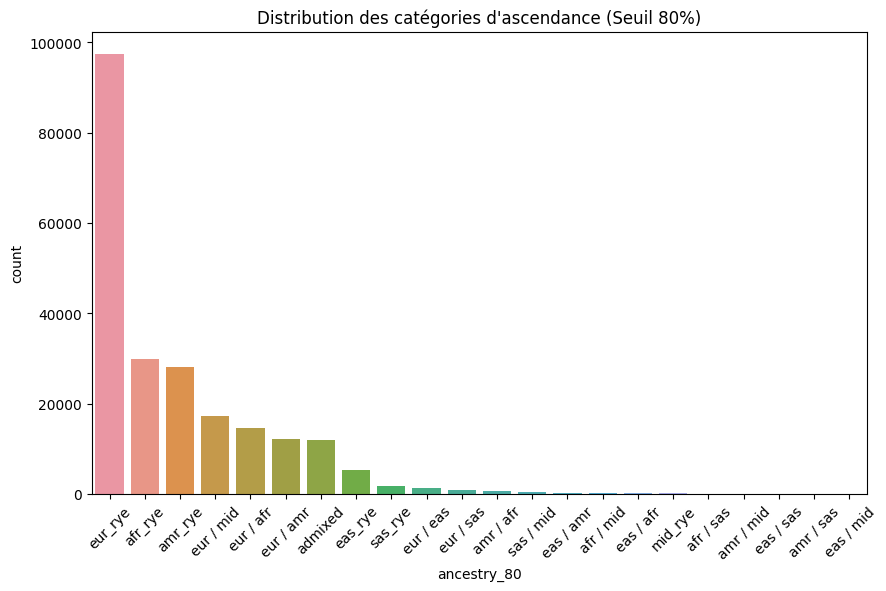

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_analysis, x='ancestry_80', order=df['ancestry_80'].value_counts().index)
plt.title('Distribution des catégories d\'ascendance (Seuil 80%)')
plt.xticks(rotation=45)
plt.show()

In [19]:
ethnie = ['eur_rye', 'afr_rye','eur / afr']

df_analysis[df_analysis['ancestry_80'].isin(ethnie)]

,person_id,has_bc,eur_rye,eas_rye,amr_rye,afr_rye,sas_rye,mid_rye,dominant_origin,ancestry_80
3,2047635,0,0.910879,0.004663,0.020749,0.000000,0.042325,0.021384,eur_rye,eur_rye
4,1608049,0,0.037236,0.011586,0.000000,0.890096,0.000000,0.061081,afr_rye,afr_rye
7,1970778,0,0.048451,0.000000,0.000000,0.951549,0.000000,0.000000,afr_rye,afr_rye
8,1734797,0,0.009882,0.000000,0.000000,0.927747,0.000000,0.062371,afr_rye,afr_rye
12,2744320,0,0.918971,0.001797,0.009895,0.000000,0.030394,0.038944,eur_rye,eur_rye
...,...,...,...,...,...,...,...,...,...,...
360872,4319948,0,0.881773,0.000000,0.054992,0.000000,0.056850,0.006386,eur_rye,eur_rye
360876,9726693,0,0.952240,0.000000,0.035841,0.000000,0.011918,0.000000,eur_rye,eur_rye
360878,3338506,0,0.948308,0.000000,0.024919,0.000000,0.026773,0.000000,eur_rye,eur_rye
360880,8355512,0,0.921728,0.000000,0.050576,0.000000,0.000438,0.027258,eur_rye,eur_rye


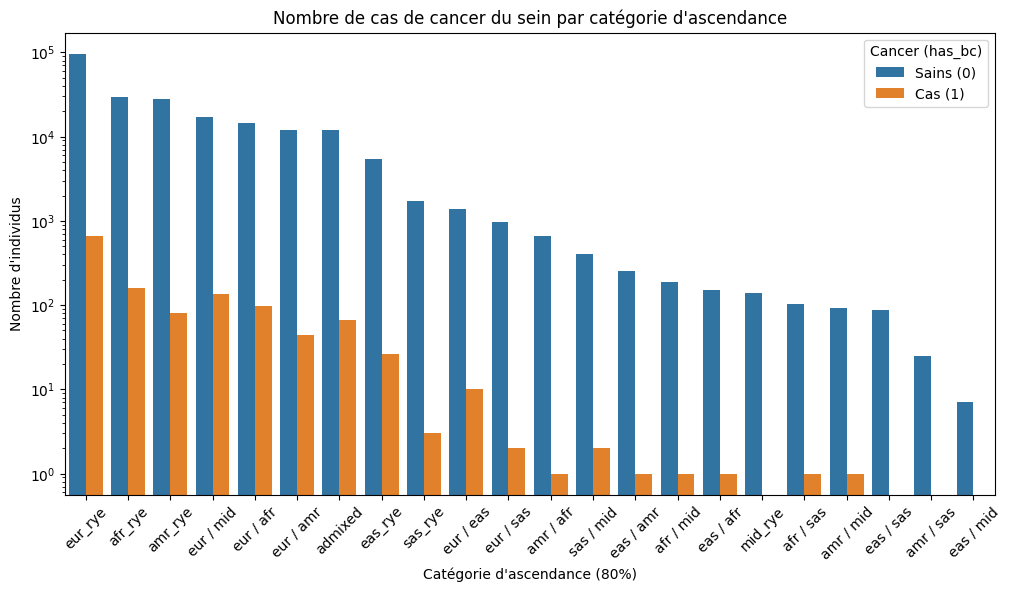

In [25]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_analysis, x='ancestry_80', hue='has_bc', 
              order=df_analysis['ancestry_80'].value_counts().index)

plt.title('Nombre de cas de cancer du sein par catégorie d\'ascendance')
plt.xlabel('Catégorie d\'ascendance (80%)')
plt.ylabel('Nombre d\'individus')
plt.xticks(rotation=45)
plt.legend(title='Cancer (has_bc)', labels=['Sains (0)', 'Cas (1)'])
plt.yscale('log') # Optionnel : échelle log si les groupes EUR sont trop dominants
plt.show()

# Data's export

In [28]:
# Enregistre le DataFrame `dataset_breast_cancer_5y_person_df` dans un fichier TSV local
destination_filename = 'df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry.tsv'
df.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}/Data/"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry.tsv [Content-Type=text/tab-separated-values]...\n/ [0 files][    0.0 B/ 42.4 MiB]                                                \r-\r- [0 files][  3.1 MiB/ 42.4 MiB]                                                \r\\\r\\ [0 files][  4.9 MiB/ 42.4 MiB]                                                \r|\r/\r/ [0 files][  6.7 MiB/ 42.4 MiB]                                                \r-\r- [0 files][  8.5 MiB/ 42.4 MiB]                                                \r\\\r|\r| [0 files][ 10.3 MiB/ 42.4 MiB]                                                \r/\r/ [0 files][ 12.1 MiB/ 42.4 MiB]                                                \r-\r- [0 files][ 13.9 MiB/ 42.4 MiB]                                                \r\\\r|\r| [0 files][ 15.7 MiB/ 42.4 MiB]                                                \r/\r/ [0 files][ 17.5 MiB/ 42.4 MiB]                                                \r-\r\\\r\\ [0 